# Análise do CICDDoS2019 01/12

## Criação do Dataset Balanceado

In [1]:
from src.Data.Handler import DatasetHandler

handler = DatasetHandler(logging=True)

handler.create_balanced_dataset(
    src_dir="C:/GitHub/anomaly-detection-data-stream/datasets/CICDDoS2019/01-12", 
    dest_dir="data", 
    output_filename="BALANCED.CSV", 
    n_samples_per_class=10000,
    chunk_size=100000,
    target_files=None,
    ignored_classes=['WebDDoS'],
    allow_insufficient=True
)

PROCESSAMENTO OTIMIZADO (CHUNKS): BALANCED.CSV
Arquivos Selecionados: 11
Tamanho do Lote (Chunksize): 100000
Classes Ignoradas: ['WebDDoS']

[*] Varredura global (Lendo em lotes)...
[*] Validando quantidades disponíveis...

[*] Coletando e Salvando em disco (Lotes de 100000)...
   -> Processando: DrDoS_DNS.csv
   -> Processando: DrDoS_LDAP.csv
   -> Processando: DrDoS_MSSQL.csv
   -> Processando: DrDoS_NetBIOS.csv
   -> Processando: DrDoS_NTP.csv
   -> Processando: DrDoS_SNMP.csv
   -> Processando: DrDoS_SSDP.csv
   -> Processando: DrDoS_UDP.csv
   -> Processando: Syn.csv
      [IO] Buffer cheio (100000 linhas). Salvando lote no disco...
   -> Processando: TFTP.csv
   -> Processando: UDPLag.csv
      [IO] Salvando lote final (20000 linhas)...

CONCLUÍDO COM SUCESSO
Arquivo gerado: data\BALANCED.CSV


## Análise de Similaridade

Limpeza: Removendo espaços, identificadores e colunas vazias...
Pré-processamento: Convertendo infinitos...
Tratamento de Nulos: Preenchendo com ZERO.
Normalização: StandardScaler
Target: Mantendo multiclasse (Forçando BENIGN=0)...
Seleção de Features: Nenhuma técnica dinâmica selecionada. Mantendo colunas atuais.
Finalização: Retornando DataFrame pandas processado.


 INICIANDO EXTRAÇÃO DE FEATURES OVR (ONE-VS-REST)
 [*] Analisando Assinatura Local: BENIGN vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_DNS vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_LDAP vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_MSSQL vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_NetBIOS vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_NTP vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_SNMP vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_SSDP vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrD

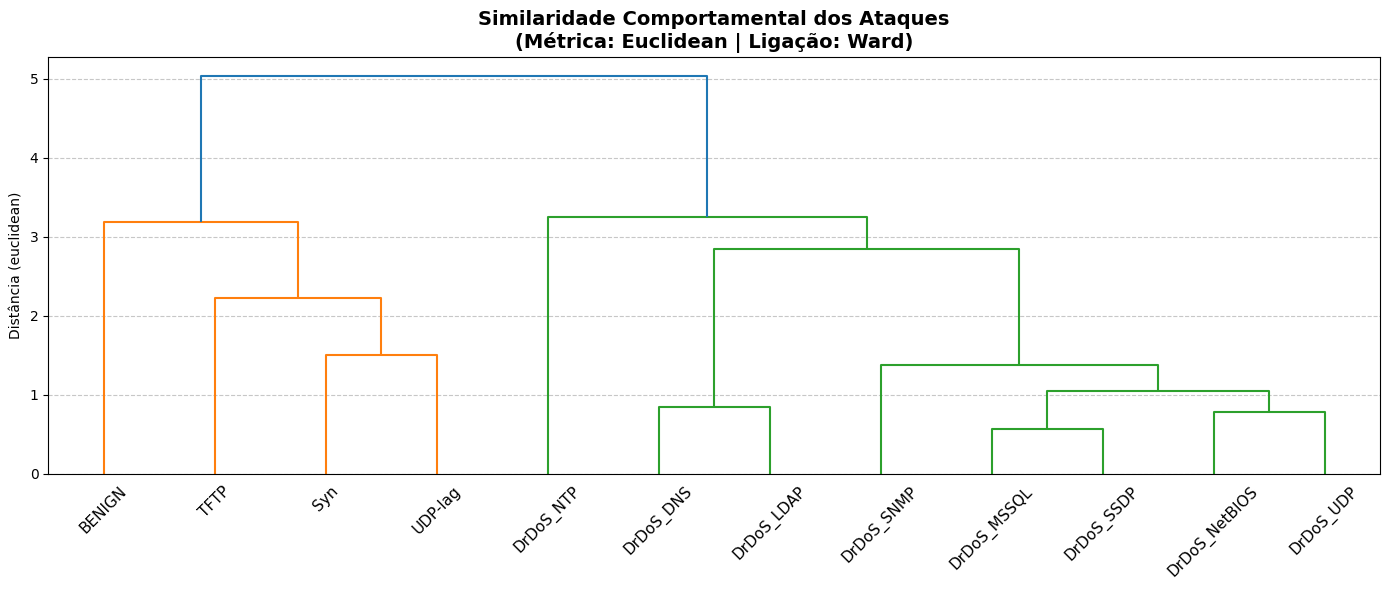


 [*] Gerando Mapa de Calor de Features (Ordenado)...


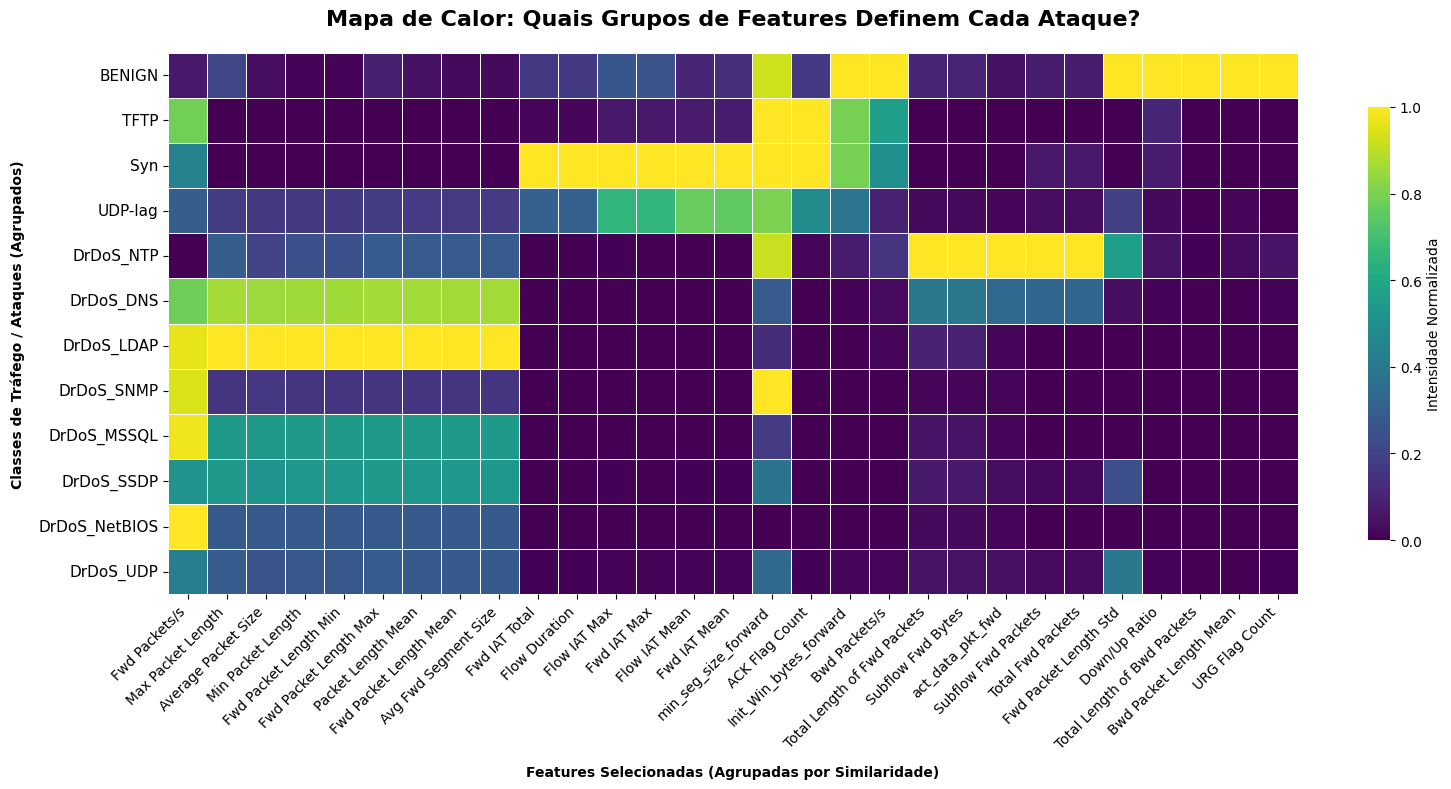

In [4]:
import pandas as pd
from src.Data.Processor import DataStreamProcessor
from src.Data.Handler import DatasetHandler

# Instancia as duas ferramentas
processor = DataStreamProcessor(logging=True)
handler = DatasetHandler(logging=True)

# Carrega o CSV 
df_bruto = pd.read_csv('data/BALANCED.CSV')

# Pré-Processamento 
X_df, y_array, target_names = processor.create_stream(
    df=df_bruto,
    target_label_col='Label',
    binary_label=False,               # Falso pois queremos ver CADA ataque separado
    normalize_method='StandardScaler',  # Normaliza entre 0 e 1
    imputation_method='0',            # Substitui NaNs por 0
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol', 'Inbound'],
    return_stream=False               # Retorna (DataFrame de Features, Array de Labels, Nomes)
)

# Executa a Seleção OvR (One-vs-Rest)
dict_features, vetor_features_finais = handler.extract_ovr_feature_importance(
    X=X_df, 
    y=y_array, 
    target_names=target_names,
    top_per_class=7 
)

# Plota os Dendrogramas e Mapas de Calor
handler.plot_similarity_and_feature_groups(
    X=X_df, 
    y=y_array, 
    target_names=target_names,
    selected_features=vetor_features_finais, 
    metric='euclidian',   # cosine / euclidian
    linkage_method='ward' # average / ward 
)

# Criando gráfico de radar

Limpeza: Removendo espaços, identificadores e colunas vazias...
Pré-processamento: Convertendo infinitos...
Tratamento de Nulos: Preenchendo com a MEDIANA das colunas...
Normalização: MinMaxScaler
Target: Mantendo multiclasse (Forçando BENIGN=0)...
Seleção de Features: Iniciando pipeline de redução de dimensionalidade...

--- Iniciando Processo de Seleção de Features (Total: 77) ---
Remoção de Variância: Pular.
Correlação (>0.9): 30 features redundantes removidas. Restantes: 47
Random Forest: Top 10 selecionadas.
Features Finais (10) - ['Fwd Packet Length Max', 'Total Length of Fwd Packets', 'Total Fwd Packets', 'Flow Duration', 'ACK Flag Count', 'Fwd Packets/s', 'Init_Win_bytes_forward', 'Flow IAT Mean', 'Packet Length Variance', 'Fwd Packet Length Std']
--- Fim do Processo de Seleção de Features ---

Finalização: Retornando DataFrame pandas processado.



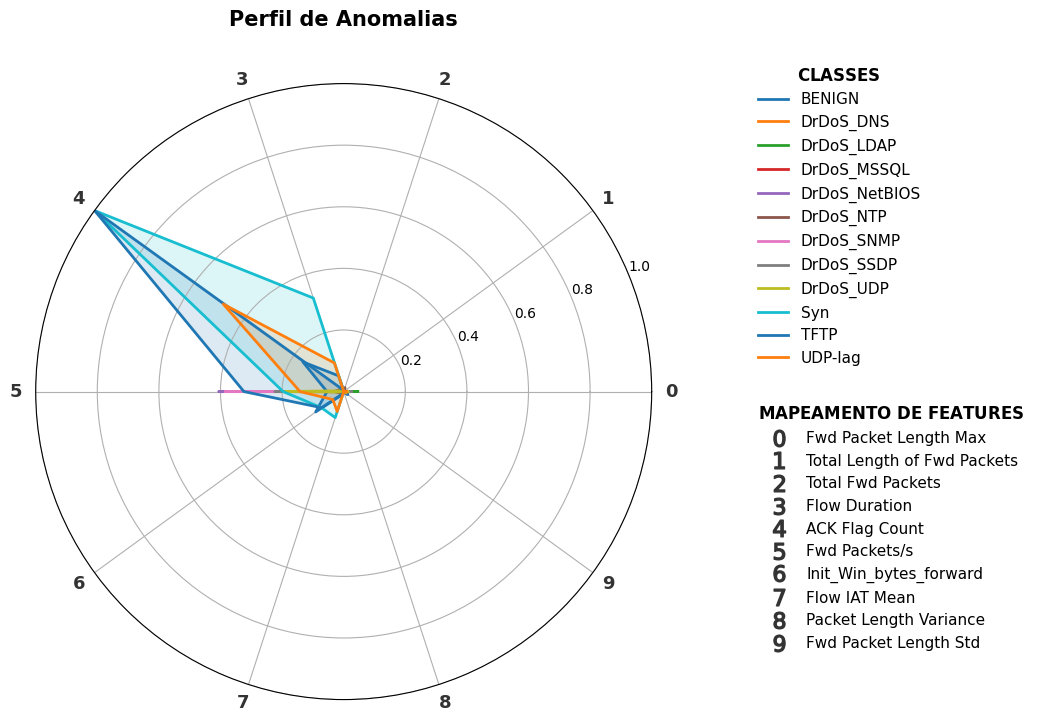

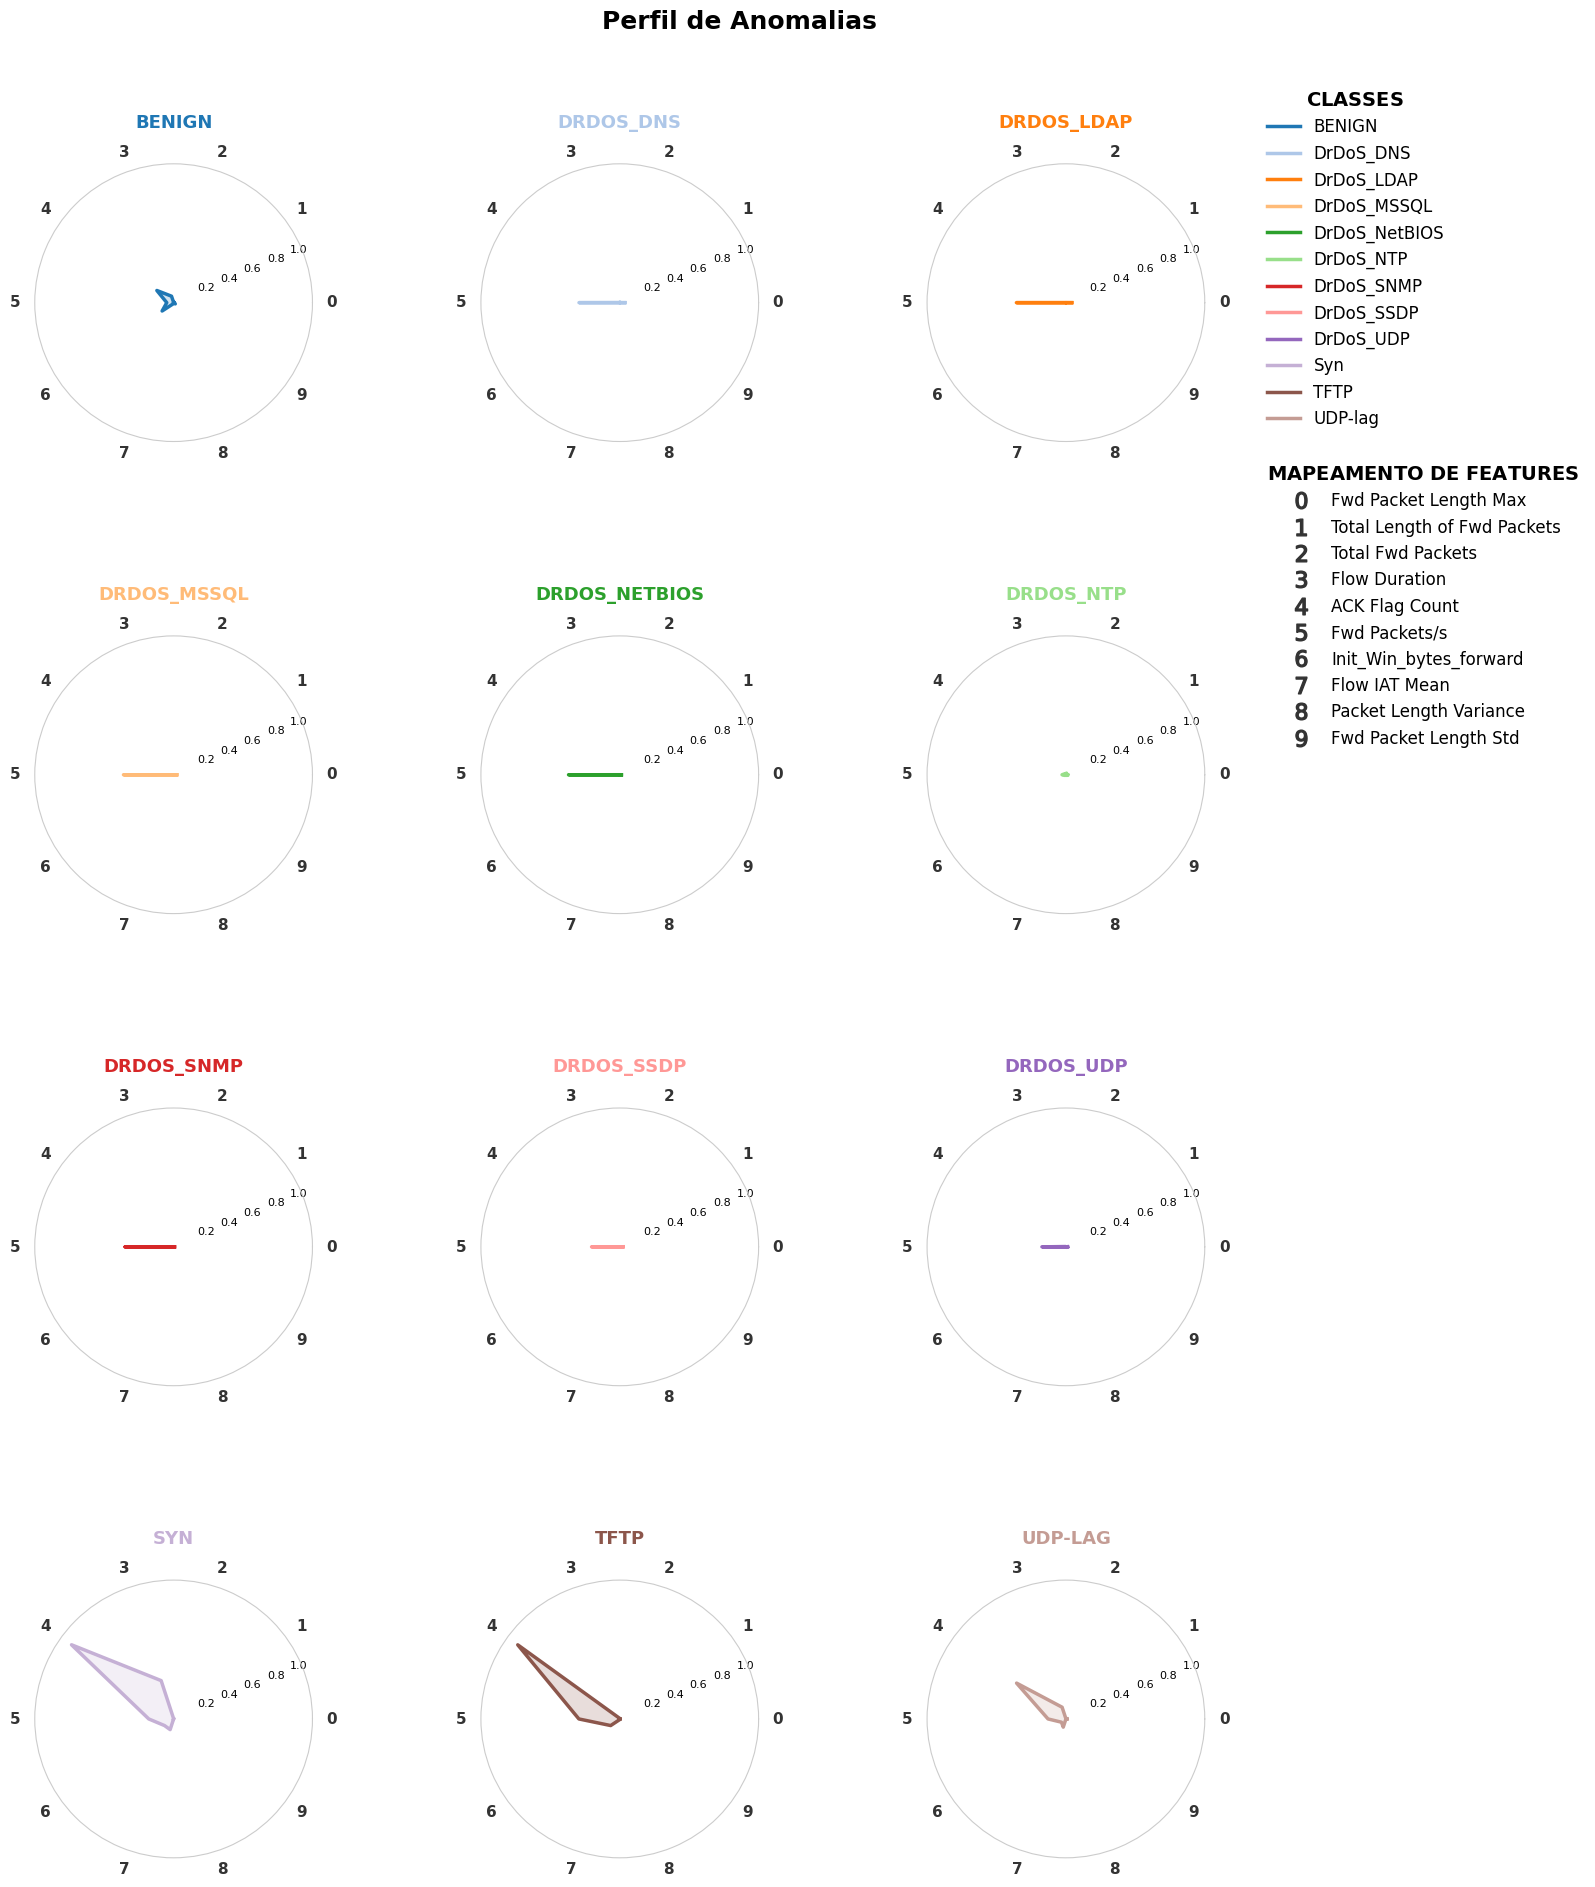

In [12]:
from src.Data.Processor import DataStreamProcessor
from src.Data.Handler import DatasetHandler
import pandas as pd

handler = DatasetHandler(logging=True)
processor = DataStreamProcessor(logging=True)

df = pd.read_csv('data/BALANCED.CSV')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=False, 
    normalize_method="MinMaxScaler", 
    threshold_var=None,
    threshold_corr=0.9,
    top_n_features=10,
    return_stream=False,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol','Inbound'],
    imputation_method='mediana'
)

handler.plot_feature_radar(stream, targets, features)
handler.plot_mini_radars(stream, targets, features)

# Criação de cenários

## Média de Amostras Normais 15k

In [1]:
AMOSTRAS = [25, 200, 1000]
BASELINE = "data/BENIGN.csv"
INPUT_FOLDER = "C:\\GitHub\\anomaly-detection-data-stream\\datasets\\CICDDoS2019\\01-12"
OUTPUT_FOLDER = "data/15k"

### Cenário de Consistência


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 25 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 25 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 25 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN       15003
DrDoS_DNS       72


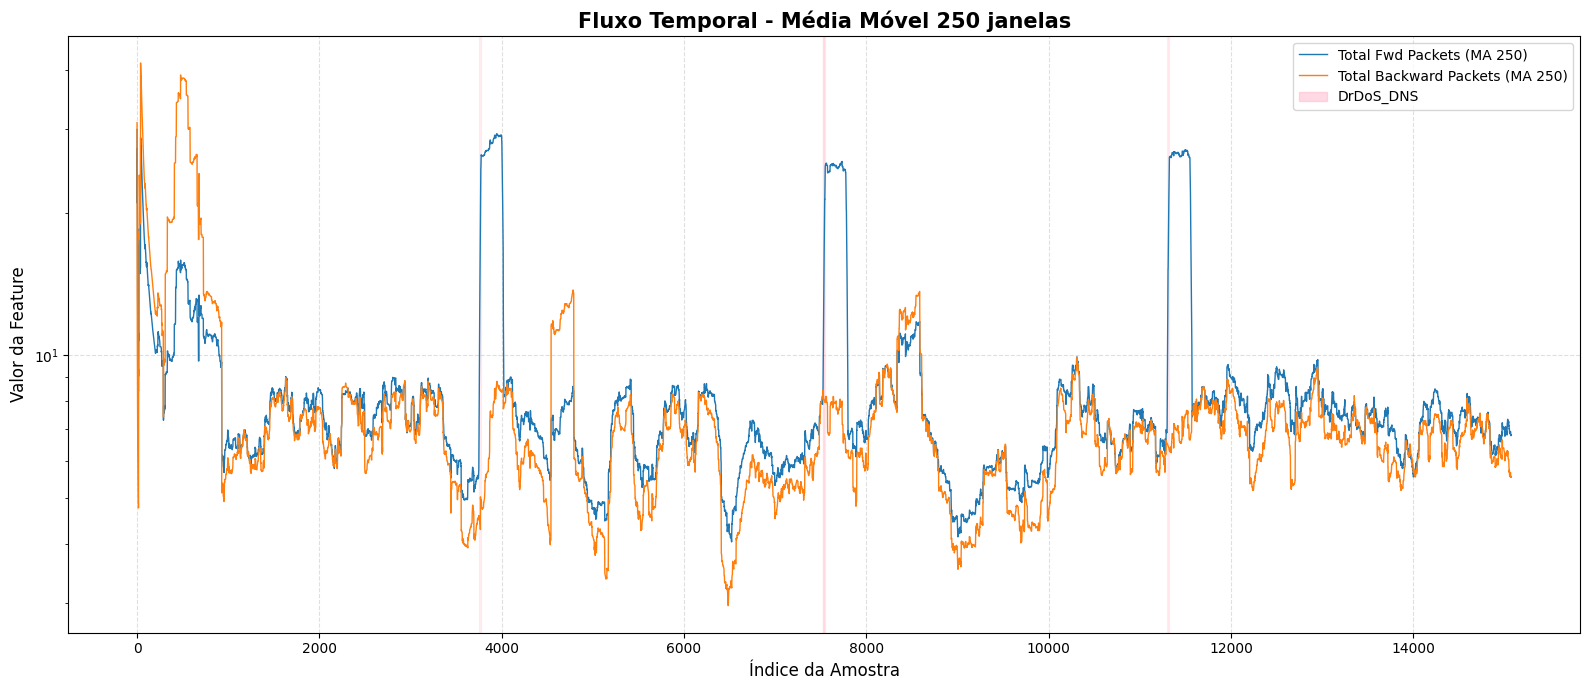


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 200 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 200 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 200 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN       15096
DrDoS_DNS      504


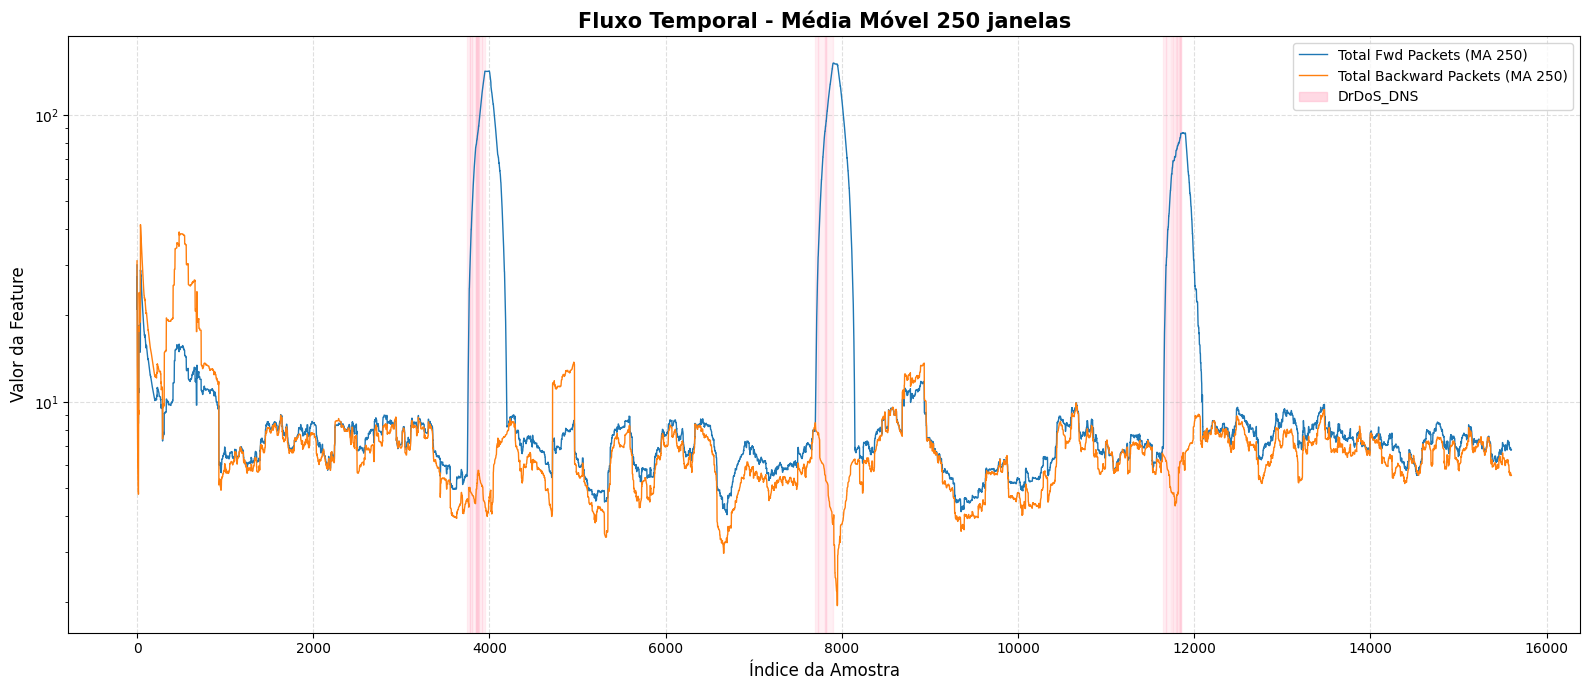


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 1000 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 1000 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 1000 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN       15507
DrDoS_DNS     2493


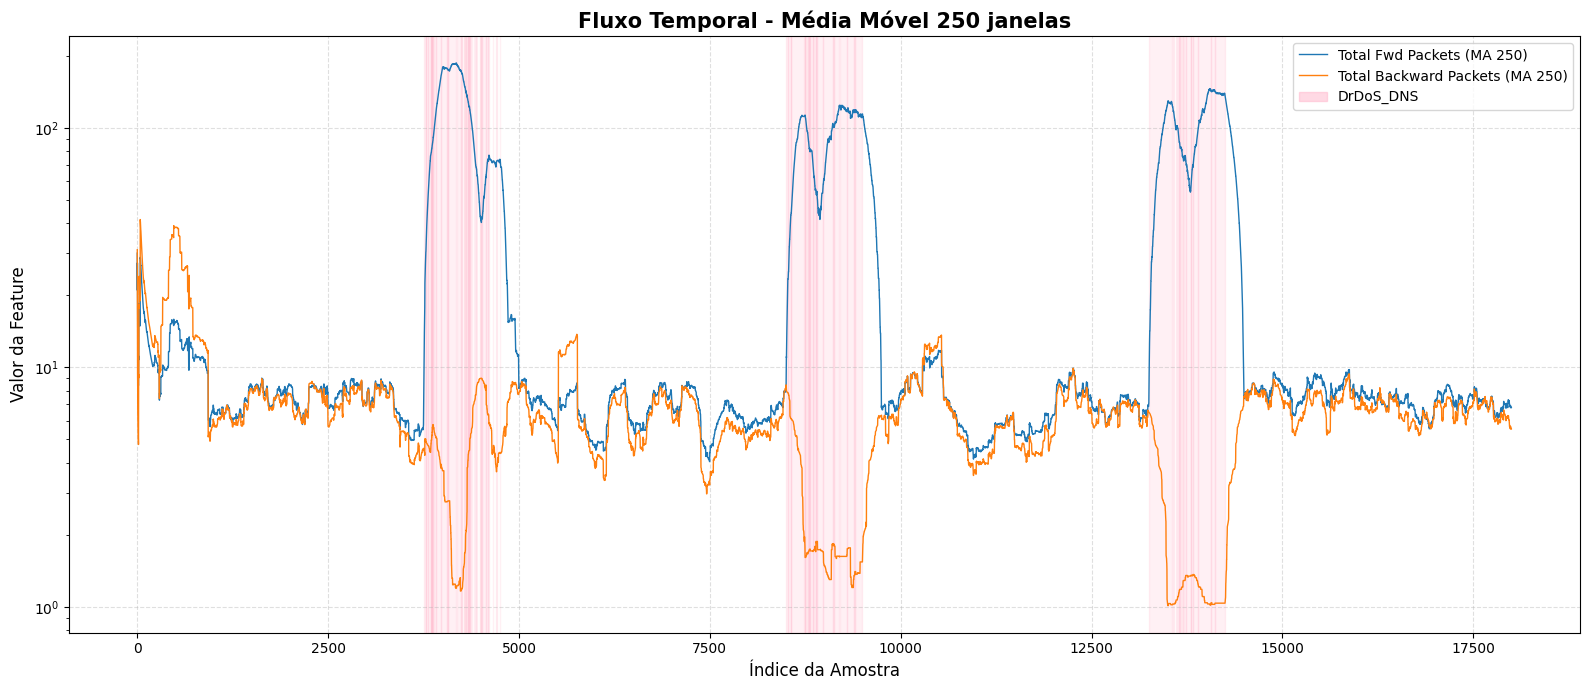

In [2]:
from src.Data.ScenarioGenerator import ScenarioGenerator

for qtd_amostras in AMOSTRAS:
    
    meu_cenario = [
        ("DrDoS_DNS.csv", qtd_amostras),
        ("DrDoS_DNS.csv", qtd_amostras),
        ("DrDoS_DNS.csv", qtd_amostras)
    ]

    caminho_saida = f"{OUTPUT_FOLDER}/Consistência/Consistência_{qtd_amostras}.csv"

    gerador = ScenarioGenerator(
        input_folder=INPUT_FOLDER,
        output_path=caminho_saida,
        baseline_file=BASELINE,
        logging=True,
        n_benign_samples=15000, 
        sort_by_timestamp=False,
        remove_duplicates=False
    )

    gerador.generate(meu_cenario)
    gerador.plot_scenario(window_size=250, features_plot=['Total Fwd Packets', 'Total Backward Packets'])

### Cenário Generalização


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 25 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 25 amostras de DrDoS_LDAP.csv (Sem filtro).
    -> Bloco montado: 25 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN        15002
DrDoS_DNS        48
DrDoS_LDAP       25


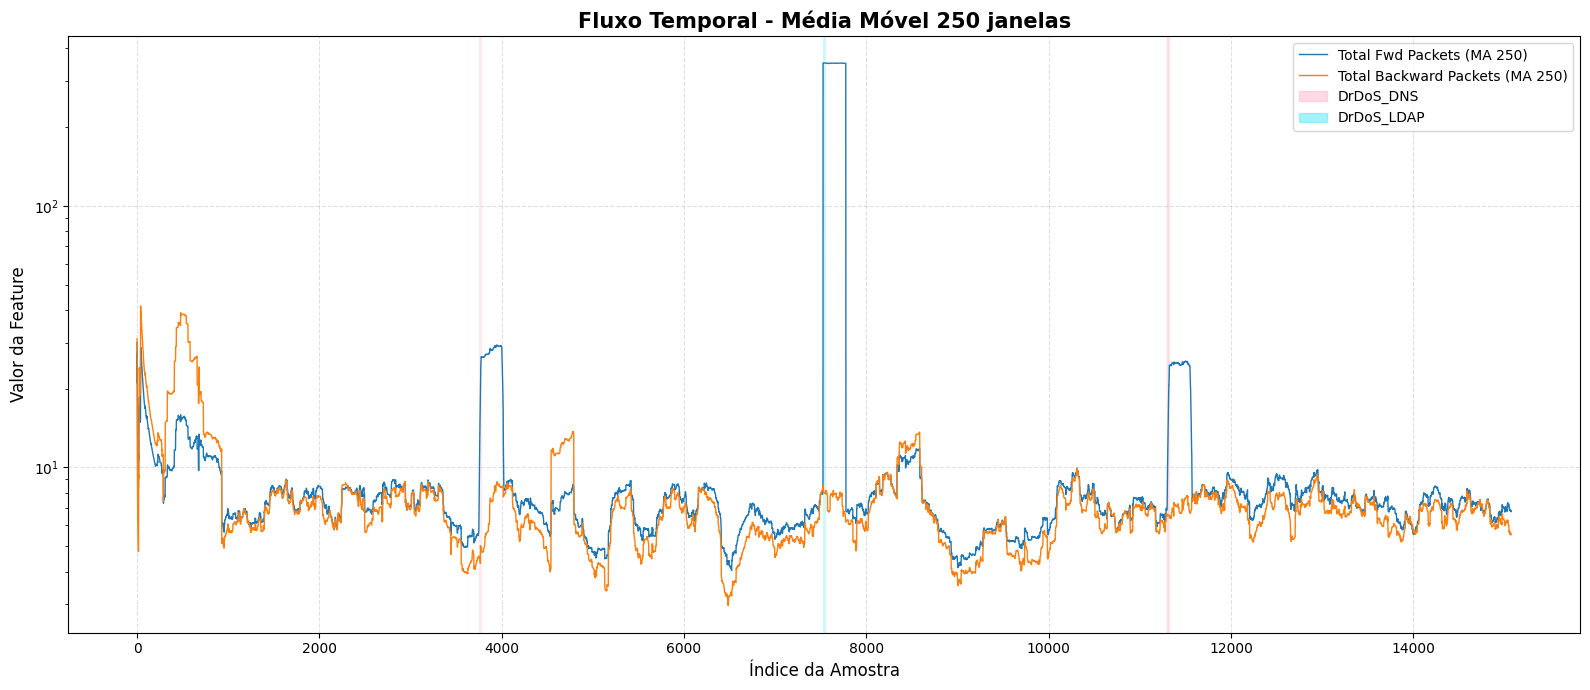


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 200 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 200 amostras de DrDoS_LDAP.csv (Sem filtro).
    -> Bloco montado: 200 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN        15028
DrDoS_DNS       372
DrDoS_LDAP      200


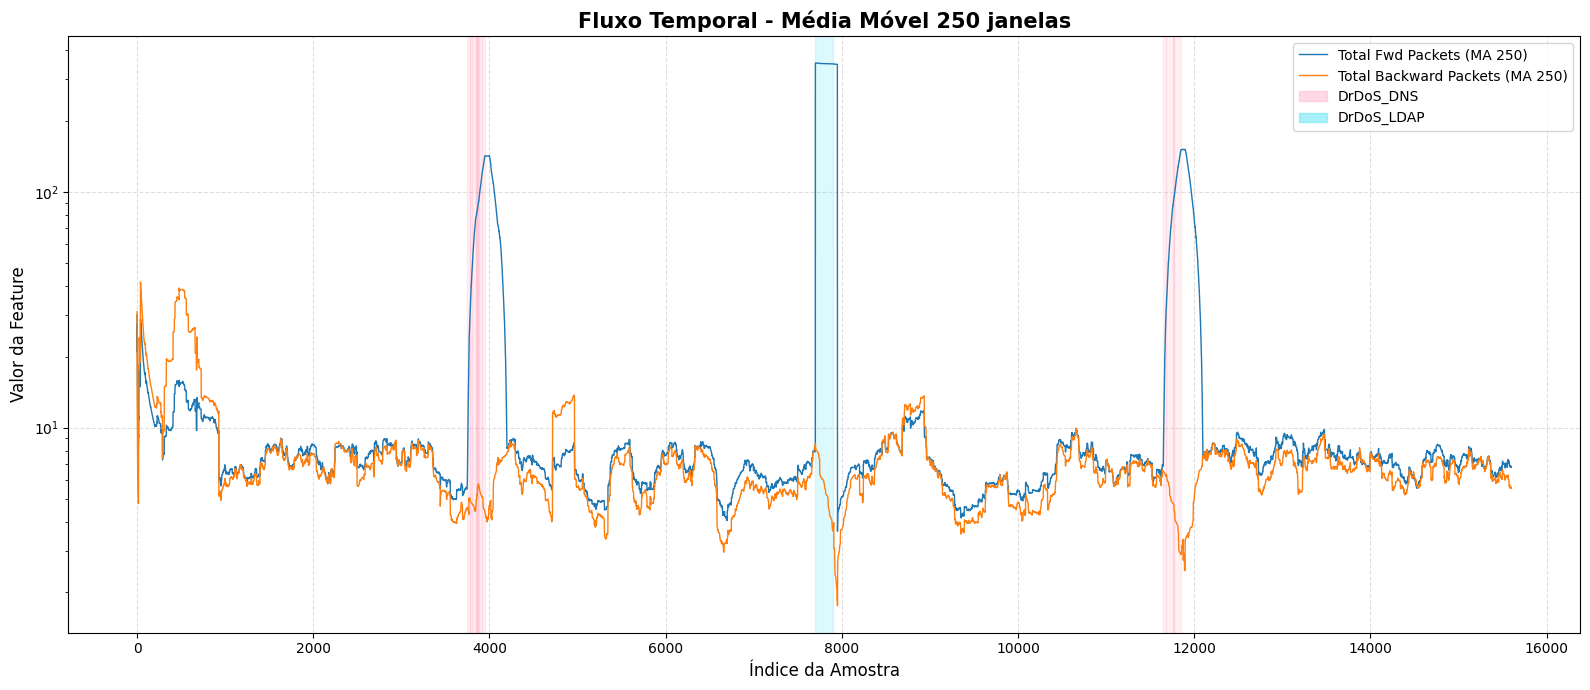


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 1000 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 1000 amostras de DrDoS_LDAP.csv (Sem filtro).
    -> Bloco montado: 1000 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN        15431
DrDoS_DNS      1569
DrDoS_LDAP     1000


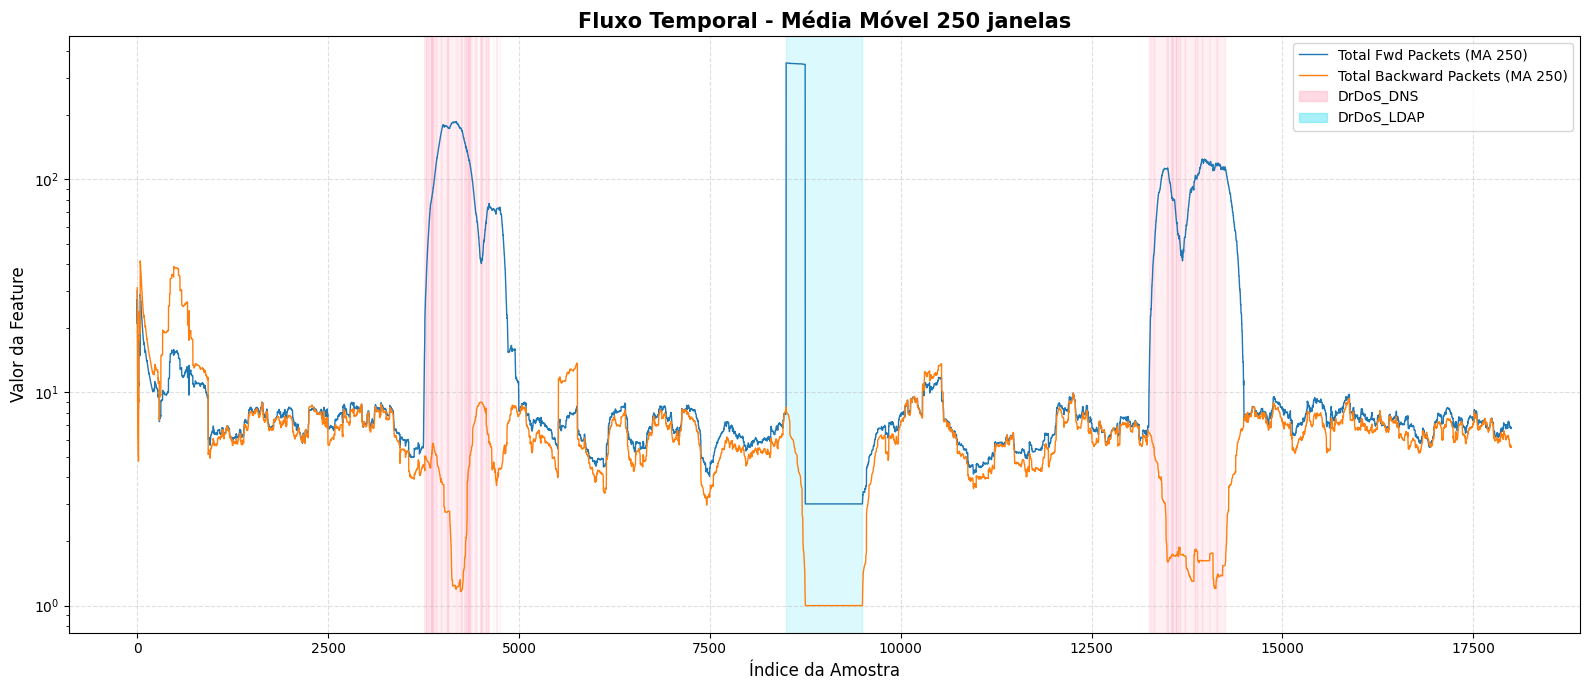

In [3]:
from src.Data.ScenarioGenerator import ScenarioGenerator

for qtd_amostras in AMOSTRAS:
    
    meu_cenario = [
        ("DrDoS_DNS.csv", qtd_amostras),
        ("DrDoS_LDAP.csv", qtd_amostras),
        ("DrDoS_DNS.csv", qtd_amostras)
    ]

    caminho_saida = f"{OUTPUT_FOLDER}/Generalização/Generalização_{qtd_amostras}.csv"

    gerador = ScenarioGenerator(
        input_folder=INPUT_FOLDER,
        output_path=caminho_saida,
        baseline_file=BASELINE,
        logging=True,
        n_benign_samples=15000, 
        sort_by_timestamp=False,
        remove_duplicates=False
    )

    gerador.generate(meu_cenario)
    gerador.plot_scenario(window_size=250, features_plot=['Total Fwd Packets', 'Total Backward Packets'])

### Cenário Adaptação


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 25 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 25 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 25 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN       15004
DrDoS_DNS       48
Syn             23


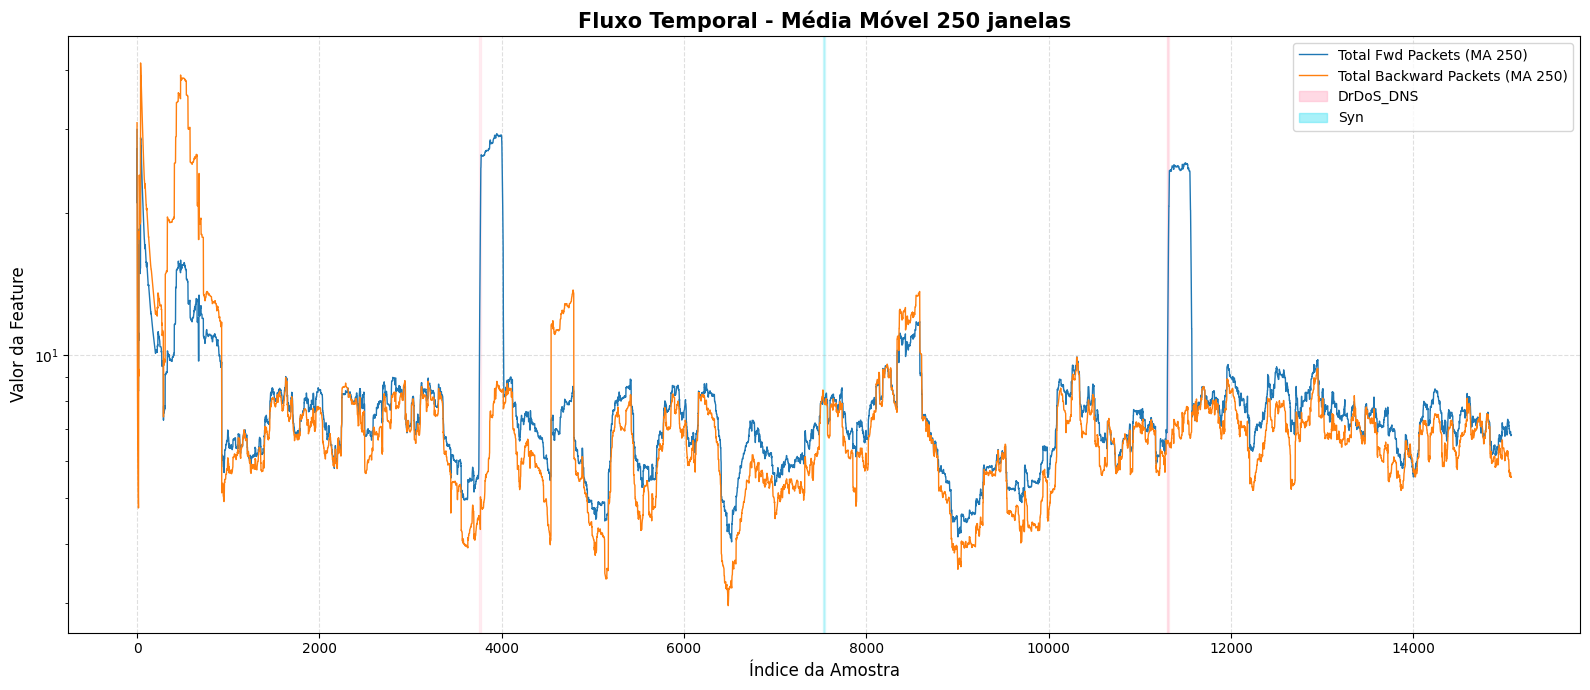


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 200 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 200 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 200 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN       15030
DrDoS_DNS      372
Syn            198


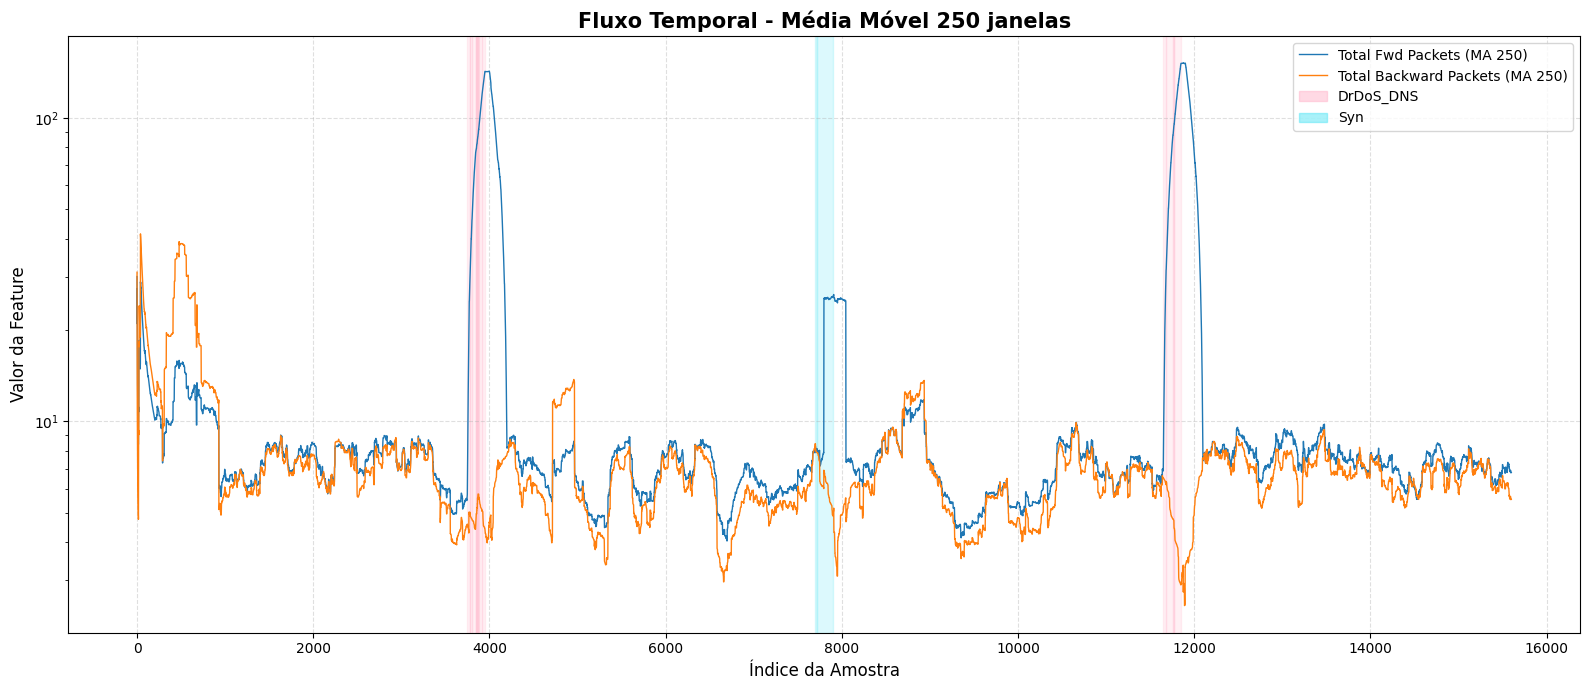


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 1000 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 1000 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 1000 amostras de DrDoS_DNS.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 4 fatias de aprox. 3750 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN       15433
DrDoS_DNS     1569
Syn            998


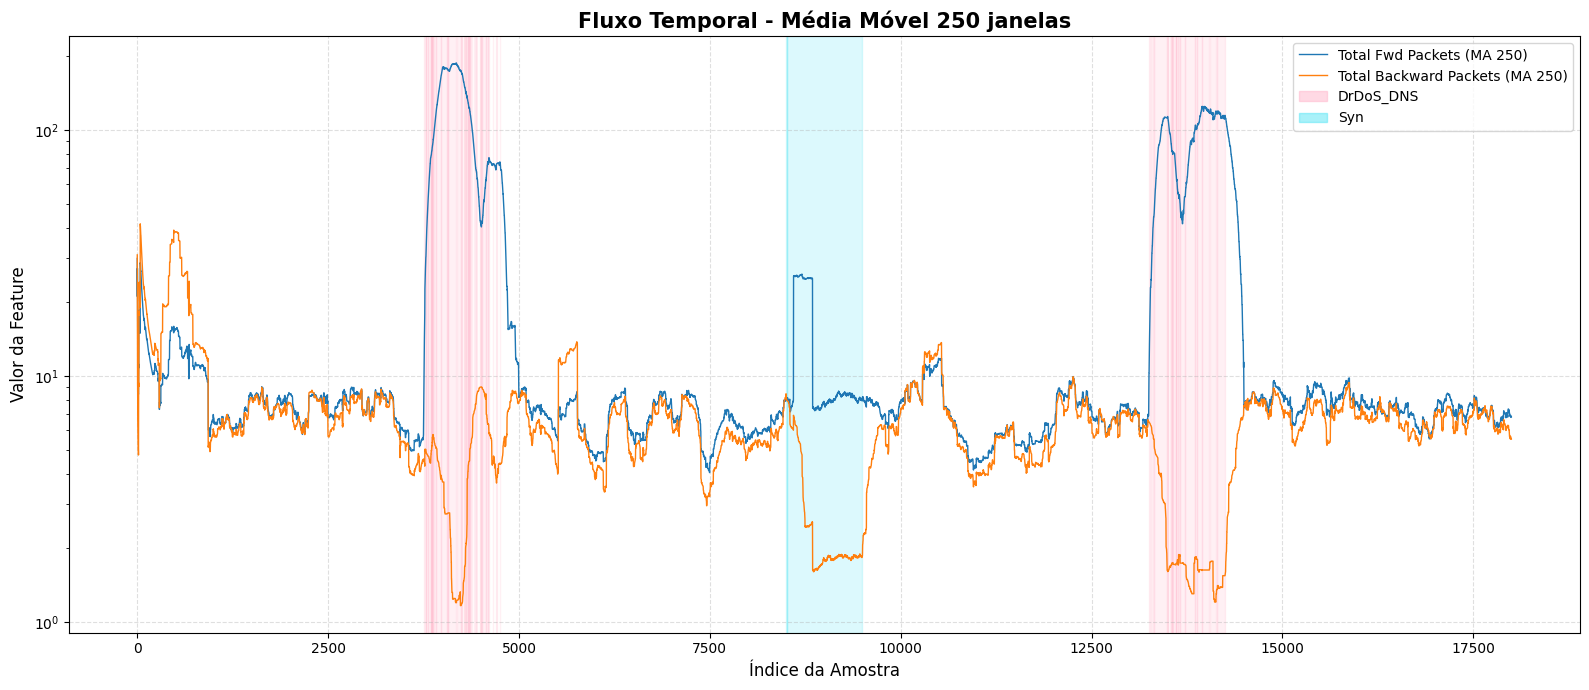

In [4]:
from src.Data.ScenarioGenerator import ScenarioGenerator

for qtd_amostras in AMOSTRAS:
    
    meu_cenario = [
        ("DrDoS_DNS.csv", qtd_amostras),
        ("Syn.csv", qtd_amostras),
        ("DrDoS_DNS.csv", qtd_amostras)
    ]

    caminho_saida = f"{OUTPUT_FOLDER}/Adaptação/Adaptação_{qtd_amostras}.csv"

    gerador = ScenarioGenerator(
        input_folder=INPUT_FOLDER,
        output_path=caminho_saida,
        baseline_file=BASELINE,
        logging=True,
        n_benign_samples=15000, 
        sort_by_timestamp=False,
        remove_duplicates=False
    )

    gerador.generate(meu_cenario)
    gerador.plot_scenario(window_size=250, features_plot=['Total Fwd Packets', 'Total Backward Packets'])

### Cenário de Recorrência


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 12 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 12 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 12 amostras de DrDoS_LDAP.csv (Sem filtro).
    -> Bloco montado: 12 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 12 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 12 amostras de DrDoS_LDAP.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 7 fatias de aprox. 2142 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN        15002
DrDoS_DNS        24
DrDoS_LDAP       24
S

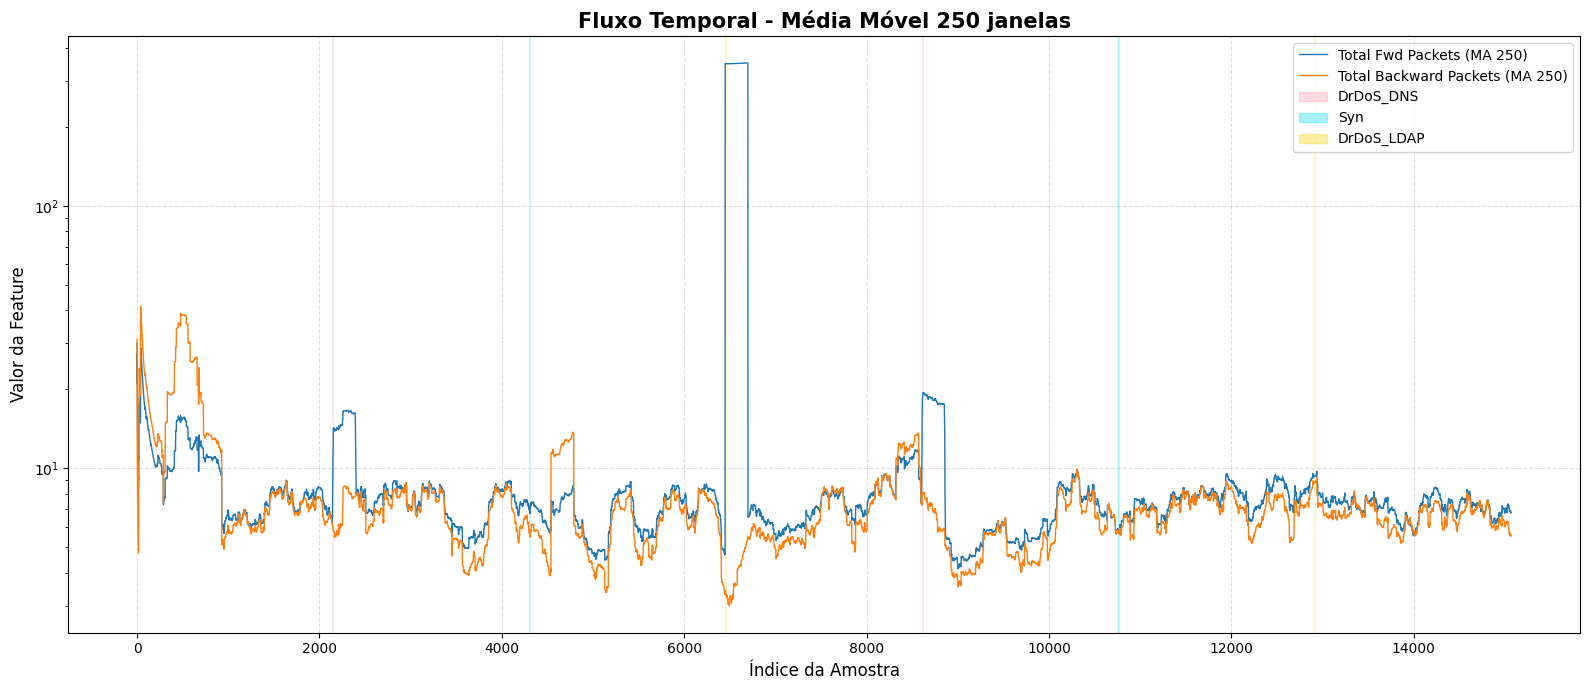


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 100 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 100 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 100 amostras de DrDoS_LDAP.csv (Sem filtro).
    -> Bloco montado: 100 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 100 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 100 amostras de DrDoS_LDAP.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 7 fatias de aprox. 2142 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN        15025
DrDoS_LDAP      200
Syn            

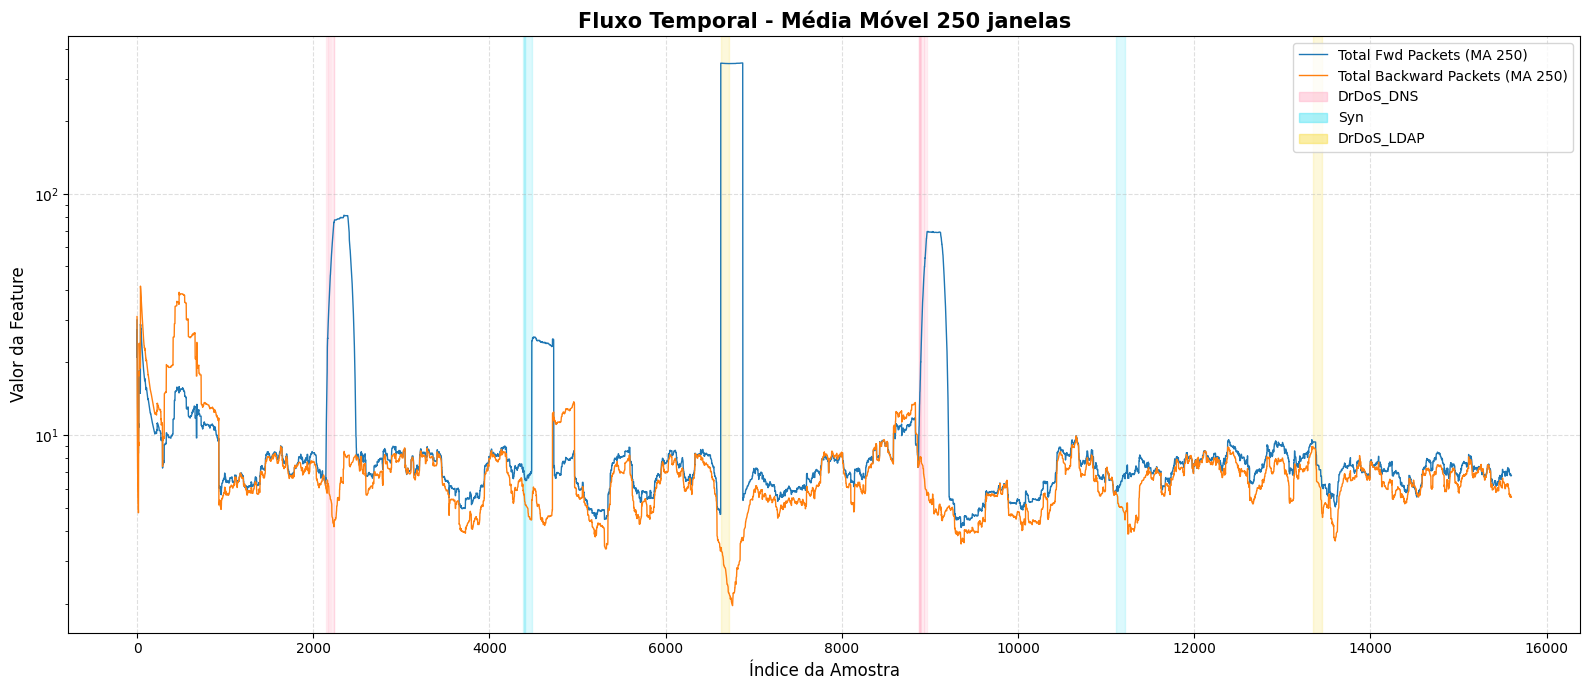


[*] Baseline BENIGN encontrado! Carregando de forma rápida...
    -> 56863 amostras BENIGN carregadas da memória.

[*] Reduzindo amostras benignas para 15000 de forma aleatória simples...
    -> Redução concluída com sucesso! Total final: 15000 amostras benignas.

[*] Coletando fatias de ataque (Linha a Linha)...
    -> Bloco montado: 500 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 500 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 500 amostras de DrDoS_LDAP.csv (Sem filtro).
    -> Bloco montado: 500 amostras de DrDoS_DNS.csv (Sem filtro).
    -> Bloco montado: 500 amostras de Syn.csv (Sem filtro).
    -> Bloco montado: 500 amostras de DrDoS_LDAP.csv (Sem filtro).

[*] Montando fluxo intercalado...
    Dividindo 15000 BENIGN em 7 fatias de aprox. 2142 linhas.
    Salvando no disco...

 SUCESSO! Cenário final salvo e pronto para Análise.
------------------------------------------------------------
Label
BENIGN        15368
DrDoS_LDAP     1000
Syn            

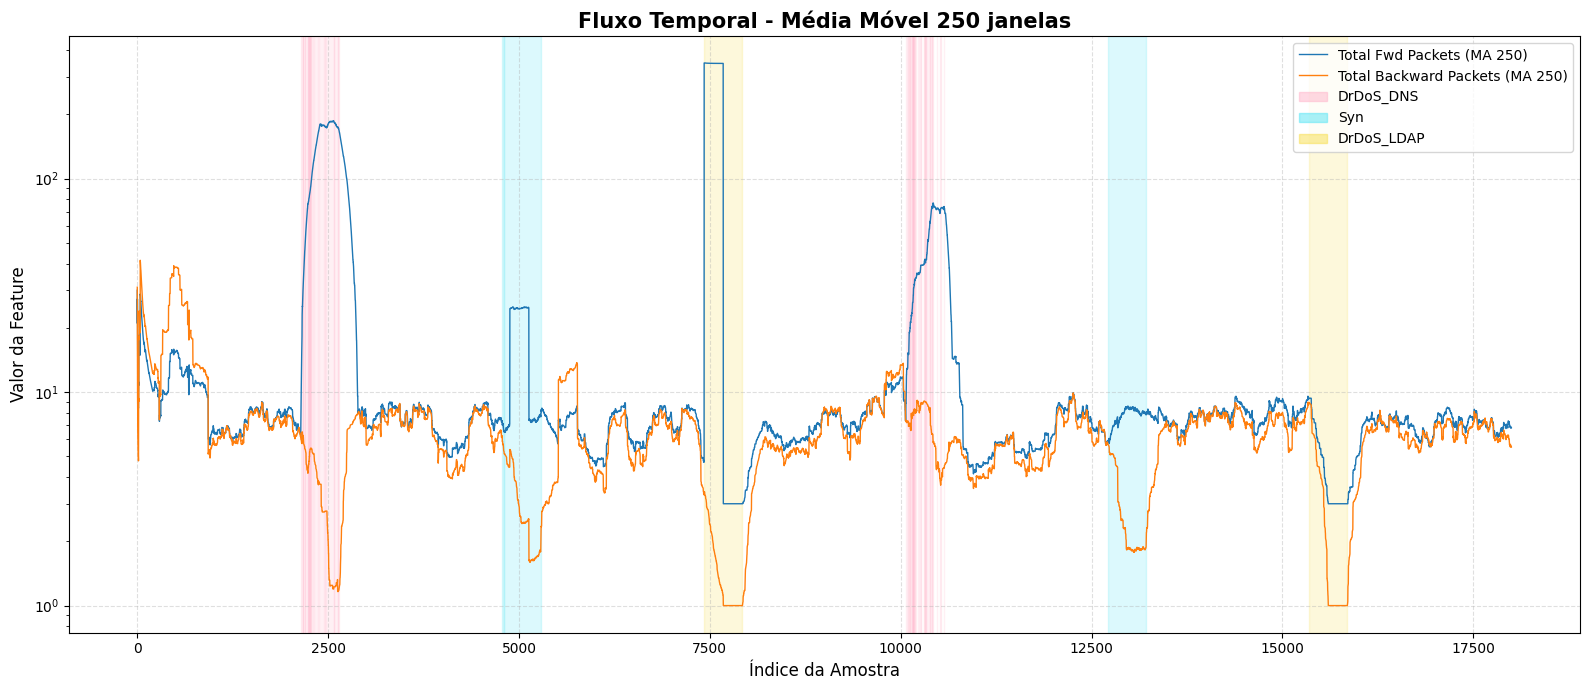

In [5]:
from src.Data.ScenarioGenerator import ScenarioGenerator

for qtd_amostras in AMOSTRAS:
    
    meu_cenario = [
        ("DrDoS_DNS.csv", qtd_amostras//2),
        ("Syn.csv", qtd_amostras//2),
        ("DrDoS_LDAP.csv", qtd_amostras//2),
        ("DrDoS_DNS.csv", qtd_amostras//2),
        ("Syn.csv", qtd_amostras//2),
        ("DrDoS_LDAP.csv", qtd_amostras//2)
    ]

    caminho_saida = f"{OUTPUT_FOLDER}/Recorrência/Recorrência_{qtd_amostras}.csv"

    gerador = ScenarioGenerator(
        input_folder=INPUT_FOLDER,
        output_path=caminho_saida,
        baseline_file=BASELINE,
        logging=True,
        n_benign_samples=15000, 
        sort_by_timestamp=False,
        remove_duplicates=False
    )

    gerador.generate(meu_cenario)
    gerador.plot_scenario(window_size=250, features_plot=['Total Fwd Packets', 'Total Backward Packets'])